# TFM pipeline mejorado

Notebook reescrito para entrenamiento, comparación metodológica y validación externa con pausa manual para CD-HIT.

In [1]:

# =========================================================
# 0. IMPORTS Y CONFIGURACIÓN
# =========================================================

import re
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from Bio import SeqIO
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from bs4 import BeautifulSoup

from sklearn.base import clone
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_score,
    recall_score
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
np.random.seed(42)

OUTPUT_DIR = Path("output_tfm")
OUTPUT_DIR.mkdir(exist_ok=True)

valid_aa = set("ACDEFGHIKLMNPQRSTVWY")

In [2]:

# =========================================================
# 1. FUNCIONES AUXILIARES
# =========================================================

def load_fasta(file, label, source):
    rows = []
    for record in SeqIO.parse(file, "fasta"):
        seq = str(record.seq).upper().strip()
        if not seq:
            continue
        if not all(a in valid_aa for a in seq):
            continue
        if not (50 <= len(seq) <= 400):
            continue
        rows.append({
            "Protein_ID": record.id,
            "Sequence": seq,
            "Length": len(seq),
            "Label": label,
            "Source": source
        })
    return pd.DataFrame(rows)


def parse_clstr(clstr_file):
    clusters = {}
    cluster_id = None
    with open(clstr_file, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line.startswith(">Cluster"):
                cluster_id = line.replace(">", "").strip()
                continue
            parts = line.split(">")
            if len(parts) < 2:
                continue
            protein = parts[1].split("...")[0].strip()
            clusters[protein] = cluster_id
    return clusters


def load_signalp(signalp_file):
    signalp = pd.read_csv(signalp_file, sep="	", comment=None, skiprows=1)
    signalp.columns = signalp.columns.str.replace("#", "", regex=False).str.strip()
    signalp = signalp.rename(columns={"ID": "Protein_ID", "SP(Sec/SPI)": "SP_probability"})
    signalp["SP_present"] = (signalp["Prediction"] == "SP").astype(int)
    signalp = signalp[["Protein_ID", "SP_probability", "SP_present"]].copy()
    return signalp


def load_tmhmm(html_file):
    with open(html_file, "r", encoding="utf-8") as f:
        soup = BeautifulSoup(f, "html.parser")
    pre = soup.find("pre")
    if pre is None:
        raise ValueError(f"No se encontró bloque <pre> en {html_file}")
    tmhmm_rows = []
    for line in pre.get_text().splitlines():
        line = line.strip()
        if not line:
            continue
        parts = line.split("	")
        protein_id = parts[0]
        data = {}
        for item in parts[1:]:
            if "=" in item:
                k, v = item.split("=", 1)
                data[k] = v
        tmhmm_rows.append({
            "Protein_ID": protein_id,
            "ExpAA": float(data.get("ExpAA", 0)),
            "PredHel": int(float(data.get("PredHel", 0))),
            "Topology": data.get("Topology", "unknown")
        })
    tmhmm = pd.DataFrame(tmhmm_rows)
    tmhmm["TM_present"] = (tmhmm["PredHel"] > 0).astype(int)
    return tmhmm


def extract_features(seq):
    prot = ProteinAnalysis(seq)
    aa = prot.amino_acids_percent
    feats = {
        "Length": len(seq),
        "MolecularWeight": prot.molecular_weight(),
        "Aromaticity": prot.aromaticity(),
        "Instability": prot.instability_index(),
        "IsoelectricPoint": prot.isoelectric_point(),
        "Gravy": prot.gravy(),
        "CysPercent": aa["C"]
    }
    for aa_name, value in aa.items():
        if aa_name == "C":
            continue
        feats[aa_name] = value
    return feats


def build_features(df, include_labels=True):
    rows = []
    for _, row in df.iterrows():
        feats = extract_features(row["Sequence"])
        feats["SP_probability"] = row.get("SP_probability", 0)
        feats["SP_present"] = row.get("SP_present", 0)
        feats["ExpAA"] = row.get("ExpAA", 0)
        feats["PredHel"] = row.get("PredHel", 0)
        feats["TM_present"] = row.get("TM_present", 0)
        feats["Protein_ID"] = row["Protein_ID"]
        if "Cluster" in row.index:
            feats["Cluster"] = row["Cluster"]
        if include_labels and "Label" in row.index:
            feats["Label"] = row["Label"]
        rows.append(feats)
    return pd.DataFrame(rows)


def bootstrap_ci(y_true, values, metric_fn, n_iter=1000, ci=95, seed=42):
    y_true = np.asarray(y_true)
    values = np.asarray(values)
    rng = np.random.default_rng(seed)
    scores = []
    n = len(y_true)
    for _ in range(n_iter):
        idx = rng.integers(0, n, size=n)
        yt = y_true[idx]
        yp = values[idx]
        if metric_fn is roc_auc_score and len(np.unique(yt)) < 2:
            continue
        scores.append(metric_fn(yt, yp))
    alpha = (100 - ci) / 2
    return float(np.mean(scores)), float(np.percentile(scores, alpha)), float(np.percentile(scores, 100 - alpha))


def detect_motifs(seq):
    found = []
    motif_rules = [
        ("RXLR-dEER", [r"R.LR", r"[DE]{1,2}E[RK]"]),
        ("YFWxC", [r"[YFW].[A-Z]?C"]),
        ("LysM_dual", [r"GD[A-Z]TC", r"WNP"]),
        ("EAR-II", [r"DLN..P"]),
        ("CRN", [r"L.LFLAK", r"HVLVI..P"]),
        ("CFEM", [r"C.{4,8}C.{4,8}C.{4,8}C"]),
        ("LixAR", [r"[LI].[A]R"]),
        ("ToxA-like", [r"TOXA", r"RGD"]),
    ]
    for name, patterns in motif_rules:
        ok = True
        for pat in patterns:
            if not re.search(pat, seq):
                ok = False
                break
        if ok:
            found.append(name)
    return ";".join(found) if found else "-"

In [3]:

# =========================================================
# 2. CARGA DEL DATASET DE ENTRENAMIENTO Y FASTA GLOBAL
# =========================================================

positive_files = [
    ("EffectorSequences_EffectorP_2_0(Train).fasta", 1, "effector_train"),
    ("EffectorSequences_EffectorP_2_0_Validation(VAL).fasta", 1, "effector_val"),
    ("Suppl_data_set_S1.fasta", 1, "S1")
]

negative_files = [
    ("Suppl_data_set_S2.fasta", 0, "S2"),
    ("Suppl_data_set_S3.fasta", 0, "S3"),
    ("Suppl_data_set_S4.fasta", 0, "S4"),
    ("phi_accessions_unaffected_pathogenicity(900).fa", 0, "PHI")
]

dfs = []
for f, l, s in positive_files + negative_files:
    df_tmp = load_fasta(f, l, s)
    print(s, df_tmp.shape)
    dfs.append(df_tmp)

df_all = pd.concat(dfs, ignore_index=True).drop_duplicates("Sequence").reset_index(drop=True)

print()
print("Total secuencias únicas:")
print(df_all.shape)
print()
print("Distribución clases:")
print(df_all["Label"].value_counts())

with open("all.fasta", "w", encoding="utf-8") as out:
    for _, row in df_all.iterrows():
        out.write(f">{row['Protein_ID']}\n{row['Sequence']}\n")

print()
print("FASTA global generado: all.fasta")

effector_train (92, 5)
effector_val (19, 5)
S1 (148, 5)
S2 (172, 5)
S3 (99, 5)
S4 (344, 5)
PHI (234, 5)

Total secuencias únicas:
(857, 5)

Distribución clases:
Label
0    694
1    163
Name: count, dtype: int64

FASTA global generado: all.fasta


In [ ]:

# =========================================================
# 3. PAUSA MANUAL PARA CD-HIT (ENTRENAMIENTO)
# =========================================================
# Ejecutar en terminal / WSL:
# cd-hit -i all.fasta -o all_clustered -c 0.6 -n 4 -T 4 -d 0

In [4]:

# =========================================================
# 4. FEATURES BIOLÓGICAS, SPLIT HOMOLOGY-AWARE Y MATRICES
# =========================================================

clusters_map = parse_clstr("all_clustered.clstr")
df_all["Cluster"] = df_all["Protein_ID"].map(clusters_map)
df_all = df_all.dropna(subset=["Cluster"]).copy()

signalp = load_signalp("Signal_result_ALL_TRAINING_SEQUENCES.txt")
tmhmm = load_tmhmm("TMHMM_result_ALL_TRAINING_SEQUENCES.html")

df_all = df_all.merge(signalp, on="Protein_ID", how="left")
df_all = df_all.merge(tmhmm, on="Protein_ID", how="left")

for col in ["SP_probability", "SP_present", "ExpAA", "PredHel", "TM_present"]:
    df_all[col] = df_all[col].fillna(0)
df_all["Topology"] = df_all["Topology"].fillna("unknown")

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df_all, df_all["Label"], groups=df_all["Cluster"]))
train_df = df_all.iloc[train_idx].copy()
test_df = df_all.iloc[test_idx].copy()

train_feat = build_features(train_df, include_labels=True)
test_feat = build_features(test_df, include_labels=True)

X_train = train_feat.drop(columns=["Label", "Protein_ID", "Cluster"], errors="ignore")
y_train = train_feat["Label"].astype(int)
X_test = test_feat.drop(columns=["Label", "Protein_ID", "Cluster"], errors="ignore")
y_test = test_feat["Label"].astype(int)

feature_cols = X_train.columns.tolist()
X_test = X_test[feature_cols]

joblib.dump(feature_cols, OUTPUT_DIR / "feature_cols.joblib")

print("Clusters únicos:", df_all["Cluster"].nunique())
print("Train:", train_df.shape)
print("Test:", test_df.shape)
print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)
print()
print("Overlap clusters train/test:", len(set(train_df["Cluster"]) & set(test_df["Cluster"])))
print()
print("SP_present por clase (train):")
print(train_df.groupby("Label")["SP_present"].mean())
print()
print("SP_present por clase (test):")
print(test_df.groupby("Label")["SP_present"].mean())

Clusters únicos: 622
Train: (674, 12)
Test: (183, 12)
Shape X_train: (674, 31)
Shape X_test: (183, 31)

Overlap clusters train/test: 0

SP_present por clase (train):
Label
0    0.001876
1    0.588652
Name: SP_present, dtype: float64

SP_present por clase (test):
Label
0    0.000000
1    0.818182
Name: SP_present, dtype: float64


In [6]:

# =========================================================
# 5. ENTRENAMIENTO Y COMPARACIÓN RF vs SVM vs LR
# =========================================================

models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42))
    ]),
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
    ])
}

results = {}
for name, estimator in models.items():
    model = clone(estimator)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc_mean, acc_lo, acc_hi = bootstrap_ci(y_test.values, y_pred, accuracy_score)
    f1_mean, f1_lo, f1_hi = bootstrap_ci(y_test.values, y_pred, f1_score)
    auc_mean, auc_lo, auc_hi = bootstrap_ci(y_test.values, y_prob, roc_auc_score)
    prec_mean, prec_lo, prec_hi = bootstrap_ci(y_test.values, y_pred, precision_score)
    rec_mean, rec_lo, rec_hi = bootstrap_ci(y_test.values, y_pred, recall_score)

    results[name] = {
        "model": model,
        "pred": y_pred,
        "prob": y_prob,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "Accuracy_CI": f"[{acc_lo:.4f}, {acc_hi:.4f}]",
        "F1_CI": f"[{f1_lo:.4f}, {f1_hi:.4f}]",
        "Precision_CI": f"[{prec_lo:.4f}, {prec_hi:.4f}]",
        "Recall_CI": f"[{rec_lo:.4f}, {rec_hi:.4f}]",
        "ROC-AUC_CI": f"[{auc_lo:.4f}, {auc_hi:.4f}]",
        "classification_report": classification_report(y_test, y_pred),
        "confusion_matrix": confusion_matrix(y_test, y_pred)
    }
    print()
    print(name)
    print(results[name]["classification_report"])
    print("Accuracy:", results[name]["Accuracy"], results[name]["Accuracy_CI"])
    print("F1:", results[name]["F1"], results[name]["F1_CI"])
    print("ROC-AUC:", results[name]["ROC-AUC"], results[name]["ROC-AUC_CI"])


RandomForest
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       161
           1       1.00      0.86      0.93        22

    accuracy                           0.98       183
   macro avg       0.99      0.93      0.96       183
weighted avg       0.98      0.98      0.98       183

Accuracy: 0.9836065573770492 [0.9617, 1.0000]
F1: 0.926829268292683 [0.8235, 1.0000]
ROC-AUC: 0.9905420666290231 [0.9770, 1.0000]

SVM
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       161
           1       0.83      0.86      0.84        22

    accuracy                           0.96       183
   macro avg       0.90      0.92      0.91       183
weighted avg       0.96      0.96      0.96       183

Accuracy: 0.9617486338797814 [0.9344, 0.9891]
F1: 0.8444444444444444 [0.7199, 0.9455]
ROC-AUC: 0.9830604178430266 [0.9647, 0.9972]

LogisticRegression
              precision    recall  f1-score   

In [7]:

# =========================================================
# 6. EXPORTAR TABLAS Y MODELOS
# =========================================================

comparison_rows = []
for name, res in results.items():
    comparison_rows.append({
        "Model": name,
        "Accuracy": res["Accuracy"],
        "Accuracy_95CI": res["Accuracy_CI"],
        "Precision": res["Precision"],
        "Precision_95CI": res["Precision_CI"],
        "Recall": res["Recall"],
        "Recall_95CI": res["Recall_CI"],
        "F1": res["F1"],
        "F1_95CI": res["F1_CI"],
        "ROC_AUC": res["ROC-AUC"],
        "ROC_AUC_95CI": res["ROC-AUC_CI"]
    })

comp_df = pd.DataFrame(comparison_rows).sort_values("ROC_AUC", ascending=False).reset_index(drop=True)
comp_df.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)
print(comp_df)

rf_model = results["RandomForest"]["model"]
joblib.dump(rf_model, OUTPUT_DIR / "rf_final_model_signalp_tmhmm.joblib")
joblib.dump(results["SVM"]["model"], OUTPUT_DIR / "svm_model_signalp_tmhmm.joblib")
joblib.dump(results["LogisticRegression"]["model"], OUTPUT_DIR / "logreg_model_signalp_tmhmm.joblib")

                Model  Accuracy     Accuracy_95CI  Precision  \
0        RandomForest  0.983607  [0.9617, 1.0000]   1.000000   
1                 SVM  0.961749  [0.9344, 0.9891]   0.826087   
2  LogisticRegression  0.950820  [0.9180, 0.9781]   0.760000   

     Precision_95CI    Recall       Recall_95CI        F1           F1_95CI  \
0  [1.0000, 1.0000]  0.863636  [0.7000, 1.0000]  0.926829  [0.8235, 1.0000]   
1  [0.6562, 0.9643]  0.863636  [0.7000, 1.0000]  0.844444  [0.7199, 0.9455]   
2  [0.5909, 0.9167]  0.863636  [0.7000, 1.0000]  0.808511  [0.6667, 0.9231]   

    ROC_AUC      ROC_AUC_95CI  
0  0.990542  [0.9770, 1.0000]  
1  0.983060  [0.9647, 0.9972]  
2  0.972332  [0.9358, 1.0000]  


['output_tfm\\logreg_model_signalp_tmhmm.joblib']

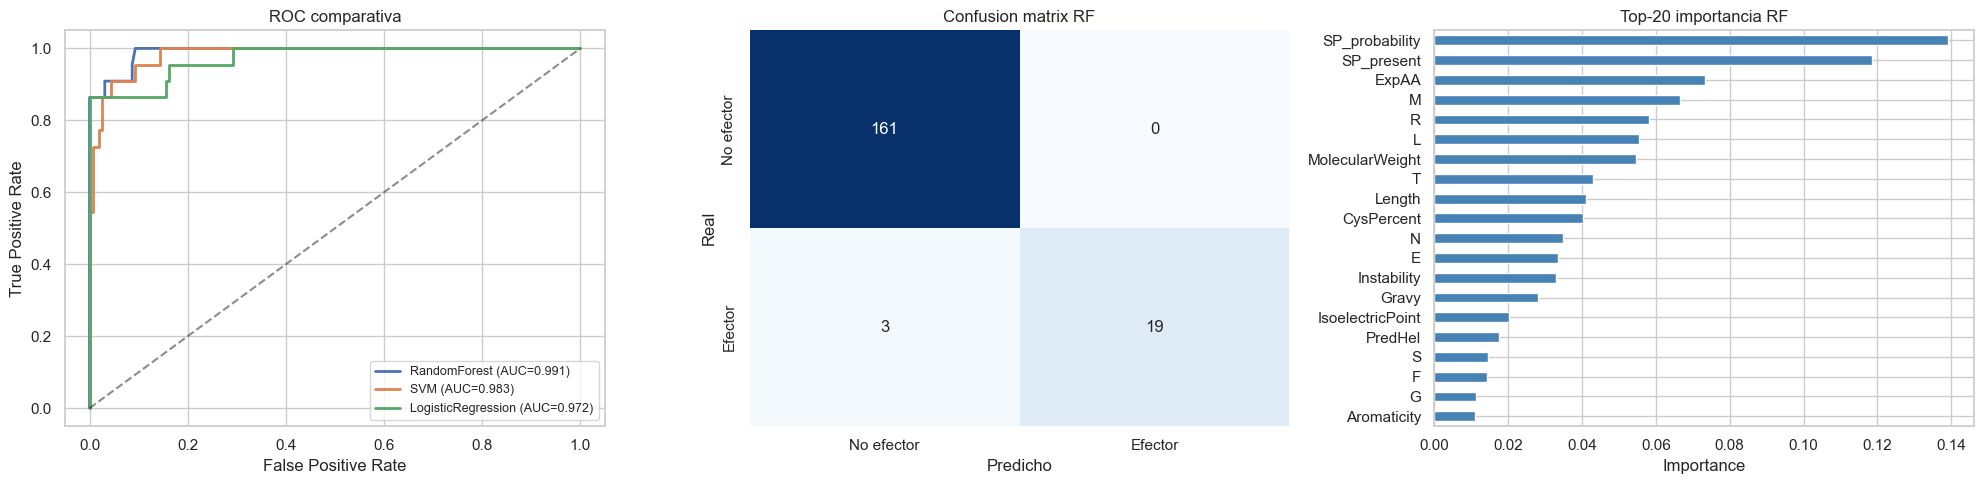

In [8]:

# =========================================================
# 7. GRÁFICOS DE COMPARACIÓN
# =========================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

ax = axes[0]
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["prob"])
    ax.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={res['ROC-AUC']:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
ax.set_title("ROC comparativa")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(fontsize=9)

ax = axes[1]
cm = results["RandomForest"]["confusion_matrix"]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
            xticklabels=["No efector", "Efector"],
            yticklabels=["No efector", "Efector"])
ax.set_title("Confusion matrix RF")
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")

ax = axes[2]
rf_importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False).head(20)
rf_importances.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top-20 importancia RF")
ax.set_xlabel("Importance")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "model_comparison_plots.png", dpi=300, bbox_inches="tight")
plt.show()

rf_importances.to_csv(OUTPUT_DIR / "rf_feature_importance_top20.csv", header=["Importance"])

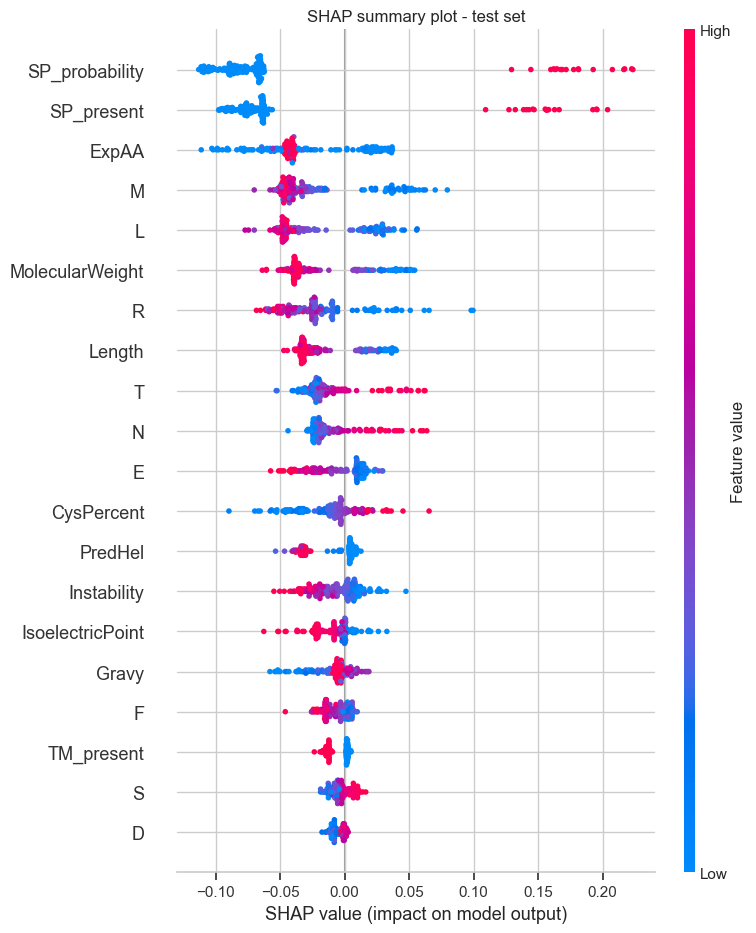

,Feature,MeanAbsSHAP
26,SP_probability,0.090671
27,SP_present,0.080704
28,ExpAA,0.042225
16,M,0.040073
15,L,0.038363
1,MolecularWeight,0.035382
20,R,0.032160
0,Length,0.028539
22,T,0.021947
17,N,0.020148


In [9]:

# =========================================================
# 8. SHAP EN TEST SET DEL ENTRENAMIENTO
# =========================================================

import shap

X_test_rf = X_test.copy()
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_rf)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values
if isinstance(sv, np.ndarray) and sv.ndim == 3:
    sv = sv[:, :, 1]

plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_test_rf, feature_names=feature_cols, plot_type="dot", show=False, max_display=20)
plt.title("SHAP summary plot - test set")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_training_test_summary.png", dpi=300, bbox_inches="tight")
plt.show()

shap_importance = pd.DataFrame({
    "Feature": feature_cols,
    "MeanAbsSHAP": np.abs(sv).mean(axis=0)
}).sort_values("MeanAbsSHAP", ascending=False)
shap_importance.to_csv(OUTPUT_DIR / "shap_training_importance.csv", index=False)
shap_importance.head(20)

In [10]:

# =========================================================
# 9. CARGA Y LIMPIEZA DEL XLSX DE CARREÓN 2024
# =========================================================

df_ext = pd.read_excel("Table S1. In silico characterization of P. fijiensis effectorome.xlsx")
print("Shape original:", df_ext.shape)
print()
print("Columnas:")
print(df_ext.columns)

protein_col = "ID JGI Pseudocercospora fijiensis"
sequence_col = "Sequence (aa)"

df_ext = df_ext.dropna(subset=[sequence_col]).copy()
df_ext[sequence_col] = df_ext[sequence_col].astype(str).str.upper().str.strip()
df_ext = df_ext[df_ext[sequence_col].apply(lambda x: all(a in valid_aa for a in x))].copy()
df_ext["Length_check"] = df_ext[sequence_col].str.len()
df_ext = df_ext[(df_ext["Length_check"] >= 50) & (df_ext["Length_check"] <= 400)].copy()
df_ext = df_ext.drop_duplicates(subset=[sequence_col]).reset_index(drop=True)

print()
print("DATASET LIMPIO:", df_ext.shape)
display(df_ext[[protein_col, sequence_col, "Length_check"]].head())

with open("carreon_2024.fasta", "w", encoding="utf-8") as out:
    for _, row in df_ext.iterrows():
        out.write(f">{row[protein_col]}\n{row[sequence_col]}\n")

df_ext.to_csv(OUTPUT_DIR / "carreon_2024_clean.csv", index=False)
print()
print("FASTA generado: carreon_2024.fasta")

Shape original: (5179, 16)

Columnas:
Index(['ID JGI Pseudocercospora fijiensis', 'Localization', 'Scaffold',
       'Sequence (aa)', 'Length', 'Predictor', 'Class of effector',
       'Cysteine (C) ', 'Cysteine %', 'Accesson domain ',
       'Description domain ',
       'log2FC pathogen-host interaction (Noar&Daub, 2016)',
       'RPKM (Conidia) (Carreón-Anguiano et al., 2023', 'Known effectors',
       'Motifs', 'Phylogenetic distribution'],
      dtype='object')

DATASET LIMPIO: (3010, 17)


,ID JGI Pseudocercospora fijiensis,Sequence (aa),Length_check
0,9960,PDDTLYCICRKAEHGAMIRCDNENCDKQCFHYPCVALTAEPKGEWL...,51
1,209825,MRPEEGRPSDELEVAQRKLCRSDEEGLQEWTQMREKLTFVFVEGSG...,51
2,169233,MSSPQLYRAPGAFYCMHTIMTIPSRRHAPNAWMGQPRSALLHLHLQ...,53
3,181269,MHWQLDYPLRARNTAKLYEQFAMGTNGSYPDFEYAVKRYKETDKVL...,54
4,181359,MTTQTSIPSVLLVLQGALNTTLGLYGILRPADWMTRVAEKFGGSIP...,54



FASTA generado: carreon_2024.fasta


In [ ]:

# =========================================================
# 10. PAUSA MANUAL PARA SIGNALP/TMHMM/CD-HIT EXTERNO
# =========================================================
# Archivos esperados antes de continuar:
# - Signal_result_CARREON_2024.txt
# - TMHMM_result_CARREON_2024.html
# - Ejecutar: cd-hit -i carreon_2024.fasta -o external_clustered -c 0.6 -n 4 -T 4 -d 0

In [18]:

# =========================================================
# 11. VALIDACIÓN EXTERNA CON RF PRINCIPAL
# =========================================================

ext_signalp = load_signalp("SignalP_Carreon.txt")
ext_tmhmm = load_tmhmm("TMHMM_Carreon.html")

ext_signalp["Protein_ID"] = ext_signalp["Protein_ID"].astype(str).str.strip()
ext_tmhmm["Protein_ID"] = ext_tmhmm["Protein_ID"].astype(str).str.strip()

ext_df = pd.DataFrame({
    "Protein_ID": df_ext[protein_col].astype(str).str.strip(),
    "Sequence": df_ext[sequence_col].astype(str),
    "Length": df_ext["Length_check"].astype(int)
})

print(ext_df["Protein_ID"].dtype)
print(ext_signalp["Protein_ID"].dtype)
print(ext_tmhmm["Protein_ID"].dtype)

ext_df = ext_df.merge(ext_signalp, on="Protein_ID", how="left")
ext_df = ext_df.merge(ext_tmhmm, on="Protein_ID", how="left")
for col in ["SP_probability", "SP_present", "ExpAA", "PredHel", "TM_present"]:
    ext_df[col] = ext_df[col].fillna(0)
ext_df["Topology"] = ext_df["Topology"].fillna("unknown")

external_clusters = parse_clstr("external_clustered.clstr")
ext_df["Cluster"] = ext_df["Protein_ID"].map(external_clusters)
max_cluster = pd.to_numeric(test_df["Cluster"].astype(str).str.replace("Cluster ", "", regex=False), errors="coerce").max()
max_cluster = 0 if pd.isna(max_cluster) else int(max_cluster)

missing_mask = ext_df["Cluster"].isna()
if missing_mask.any():
    for i, idx in enumerate(ext_df.index[missing_mask], start=1):
        ext_df.loc[idx, "Cluster"] = f"Cluster {max_cluster + i}"

ext_feat = build_features(ext_df, include_labels=False)
feature_cols = joblib.load(OUTPUT_DIR / "feature_cols.joblib")
X_external = ext_feat[feature_cols].copy()

ext_df["EffectorProbability"] = rf_model.predict_proba(X_external)[:, 1]
ext_df["PredictedLabel"] = (ext_df["EffectorProbability"] >= 0.5).astype(int)
ext_df["HighConfidence"] = (ext_df["EffectorProbability"] >= 0.90).astype(int)
ext_df["ClassOfEffector"] = np.where((ext_df["SP_present"] == 1) & (ext_df["TM_present"] == 0), "canonical", "non-canonical")
ext_df["Motifs"] = ext_df["Sequence"].apply(detect_motifs)

print("Distribución predicciones:")
print(ext_df["PredictedLabel"].value_counts())
print()
print("Alta confianza (>=0.90):", int(ext_df["HighConfidence"].sum()))
print("Probabilidad media:", ext_df["EffectorProbability"].mean())
print("Probabilidad mediana:", ext_df["EffectorProbability"].median())

display(ext_df.sort_values("EffectorProbability", ascending=False).head(20))

object
object
object
Distribución predicciones:
PredictedLabel
0    2680
1     330
Name: count, dtype: int64

Alta confianza (>=0.90): 85
Probabilidad media: 0.1690232558139535
Probabilidad mediana: 0.07666666666666666


,Protein_ID,Sequence,Length,SP_probability,SP_present,ExpAA,PredHel,Topology,TM_present,Cluster,EffectorProbability,PredictedLabel,HighConfidence,ClassOfEffector,Motifs
2240,211475,MRSTILIAFAAIIALASCAPTTDSLSGNQCTCVQVMFCKTKKAFGC...,127,0.999730,1,7.36,0,o,0,Cluster 2364,0.990000,1,1,canonical,YFWxC;CFEM
1141,52972,MHFTGAAVLGLLPALSLATPFPQNAGNSPGSNMCDASTFNNGKTYN...,161,0.999758,1,0.41,0,o,0,Cluster 2033,0.990000,1,1,canonical,-
2642,212012,MRAILTVATTLLALVSTVSATNRCNCAGVEACRKDGAWGCVDLSGN...,108,0.999670,1,1.50,0,o,0,Cluster 2561,0.983333,1,1,canonical,YFWxC;CFEM
185,209460,MANTKFLLTATLLPALVFGAVEYQIATRGCKVVPDGIARFWEADGN...,130,0.998981,1,4.69,0,o,0,Cluster 2332,0.980000,1,1,canonical,-
2840,204808,MQLSIFTLFGLSALALAAPAAVPEAAPVTAVEDAATNIFARTGSGA...,103,0.999733,1,2.84,0,o,0,Cluster 2615,0.976667,1,1,canonical,YFWxC;LixAR
2029,211186,MQLSITTLSAILAALASHPALVAANGCYSGGETWGQVADAGTIAAA...,128,0.999741,1,1.62,0,o,0,Cluster 2351,0.973333,1,1,canonical,-
2016,87167,MLSTTRITLLATFALATTSYAGTMQVRDTAPAFVCPSADITATKCL...,121,0.999773,1,5.78,0,o,0,Cluster 2427,0.973333,1,1,canonical,YFWxC;CFEM
2827,79602,MHHIISTSLFLVSLTSTSVLAADYQFHVYGLTAACPSNRDCNYSFN...,110,0.999791,1,2.81,0,o,0,Cluster 2542,0.973333,1,1,canonical,YFWxC
2831,87376,MHLLSGLALLSGLASTGLAASFCTSKFPVPRQTCVSTAPLATITTT...,87,0.999453,1,2.73,0,o,0,Cluster 2729,0.973333,1,1,canonical,YFWxC
2244,211587,MPSMRHLAALGASMAVACALSLPQGTTGPSGGFSPYPQNTSITYYN...,180,0.999606,1,2.21,0,o,0,Cluster 1847,0.970000,1,1,canonical,YFWxC


In [19]:

# =========================================================
# 12. BOOTSTRAP DE INCERTIDUMBRE EN VALIDACIÓN EXTERNA
# =========================================================

n_boot = 200
rng = np.random.default_rng(42)
boot_preds = []
for _ in range(n_boot):
    idx = rng.integers(0, len(X_train), size=len(X_train))
    Xb = X_train.iloc[idx]
    yb = y_train.iloc[idx]
    model_b = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=int(rng.integers(1, 10_000)), n_jobs=-1)
    model_b.fit(Xb, yb)
    boot_preds.append(model_b.predict_proba(X_external)[:, 1])

boot_preds = np.vstack(boot_preds)
ext_df["BootstrapProbMean"] = boot_preds.mean(axis=0)
ext_df["BootstrapProbStd"] = boot_preds.std(axis=0)
ext_df["BootstrapProbCI_low"] = np.percentile(boot_preds, 2.5, axis=0)
ext_df["BootstrapProbCI_high"] = np.percentile(boot_preds, 97.5, axis=0)

print("Bootstrap summary")
print("STD mean:", ext_df["BootstrapProbStd"].mean())
print("STD max:", ext_df["BootstrapProbStd"].max())

Bootstrap summary
STD mean: 0.030332906250869027
STD max: 0.13213797082342882


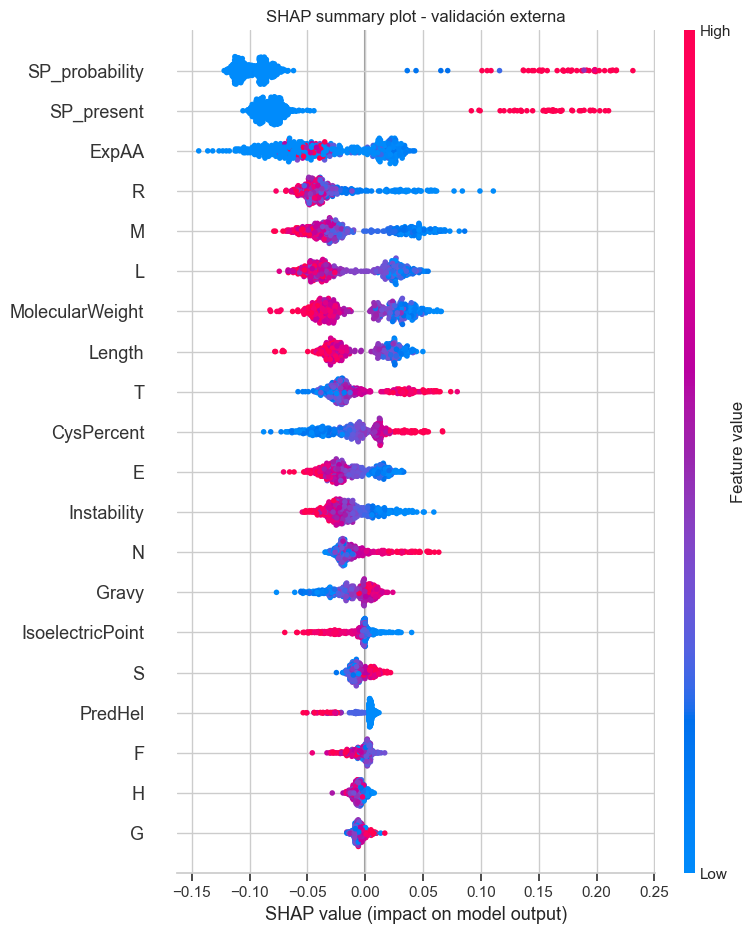

,Metric,Value
0,Total proteins,3010
1,Predicted effectors (p>=0.5),330
2,High-confidence effectors (p>=0.90),85
3,Canonical predicted effectors,279
4,Non-canonical predicted effectors,51


In [20]:

# =========================================================
# 13. SHAP EXTERNO Y EXPORTACIÓN FINAL
# =========================================================

external_sample_n = min(500, len(X_external))
external_sample_idx = np.random.default_rng(42).choice(len(X_external), size=external_sample_n, replace=False)
X_external_sample = X_external.iloc[external_sample_idx].copy()

explainer_ext = shap.TreeExplainer(rf_model)
shap_values_ext = explainer_ext.shap_values(X_external_sample)
sv_ext = shap_values_ext[1] if isinstance(shap_values_ext, list) else shap_values_ext
if isinstance(sv_ext, np.ndarray) and sv_ext.ndim == 3:
    sv_ext = sv_ext[:, :, 1]

plt.figure(figsize=(10, 7))
shap.summary_plot(sv_ext, X_external_sample, feature_names=feature_cols, plot_type="dot", show=False, max_display=20)
plt.title("SHAP summary plot - validación externa")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_external_summary.png", dpi=300, bbox_inches="tight")
plt.show()

external_shap_importance = pd.DataFrame({
    "Feature": feature_cols,
    "MeanAbsSHAP": np.abs(sv_ext).mean(axis=0)
}).sort_values("MeanAbsSHAP", ascending=False)
external_shap_importance.to_csv(OUTPUT_DIR / "shap_external_importance.csv", index=False)

ext_df_sorted = ext_df.sort_values("EffectorProbability", ascending=False).reset_index(drop=True)
ext_df_sorted.to_csv(OUTPUT_DIR / "carreon_external_predictions_rf.csv", index=False)

summary_external = pd.DataFrame({
    "Metric": [
        "Total proteins",
        "Predicted effectors (p>=0.5)",
        "High-confidence effectors (p>=0.90)",
        "Canonical predicted effectors",
        "Non-canonical predicted effectors"
    ],
    "Value": [
        len(ext_df_sorted),
        int((ext_df_sorted["PredictedLabel"] == 1).sum()),
        int((ext_df_sorted["HighConfidence"] == 1).sum()),
        int(((ext_df_sorted["PredictedLabel"] == 1) & (ext_df_sorted["ClassOfEffector"] == "canonical")).sum()),
        int(((ext_df_sorted["PredictedLabel"] == 1) & (ext_df_sorted["ClassOfEffector"] == "non-canonical")).sum())
    ]
})
summary_external.to_csv(OUTPUT_DIR / "external_validation_summary.csv", index=False)
summary_external

In [22]:

# =========================================================
# 14. MÉTRICAS DESCRIPTIVAS ADICIONALES, MOTIFS, CLUSTERS Y GRÁFICOS
# =========================================================

import math
from collections import Counter
from sklearn.decomposition import PCA


def split_motifs(series):
    motifs = []
    for val in series.fillna('-').astype(str):
        if val.strip() == '-' or val.strip() == '':
            continue
        parts = [m.strip() for m in re.split(r'[;,]+', val) if m.strip() and m.strip() != '-']
        motifs.extend(parts)
    return motifs


def motif_frequency_table(series, label='Count'):
    motifs = split_motifs(series)
    counter = Counter(motifs)
    if not counter:
        return pd.DataFrame(columns=['Motif', label])
    return pd.DataFrame(counter.items(), columns=['Motif', label]).sort_values(label, ascending=False).reset_index(drop=True)


def save_barplot(df_plot, x_col, y_col, title, xlabel, ylabel, path, color='steelblue', rotate=0):
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_plot, x=x_col, y=y_col, color=color)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=rotate)
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()


def extract_cluster_numeric(series):
    return pd.to_numeric(series.astype(str).str.replace('Cluster ', '', regex=False), errors='coerce')


Distribución motifs internas (todas):
       Motif  Count
0      YFWxC    421
1      LixAR    117
2       CFEM     24
3  RXLR-dEER     17
Distribución motifs internas (candidatas RF en test):
   Motif  CandidateCount
0  YFWxC              11
1   CFEM               3
2  LixAR               2
Frecuencia motifs dataset externo completo:
       Motif  ExternalCount
0      YFWxC           1478
1      LixAR            617
2  RXLR-dEER             74
3       CFEM             45
4     EAR-II              8
Frecuencia motifs candidatas externas RF:
       Motif  ExternalCandidateCount
0      YFWxC                     196
1      LixAR                      37
2       CFEM                      22
3  RXLR-dEER                       1


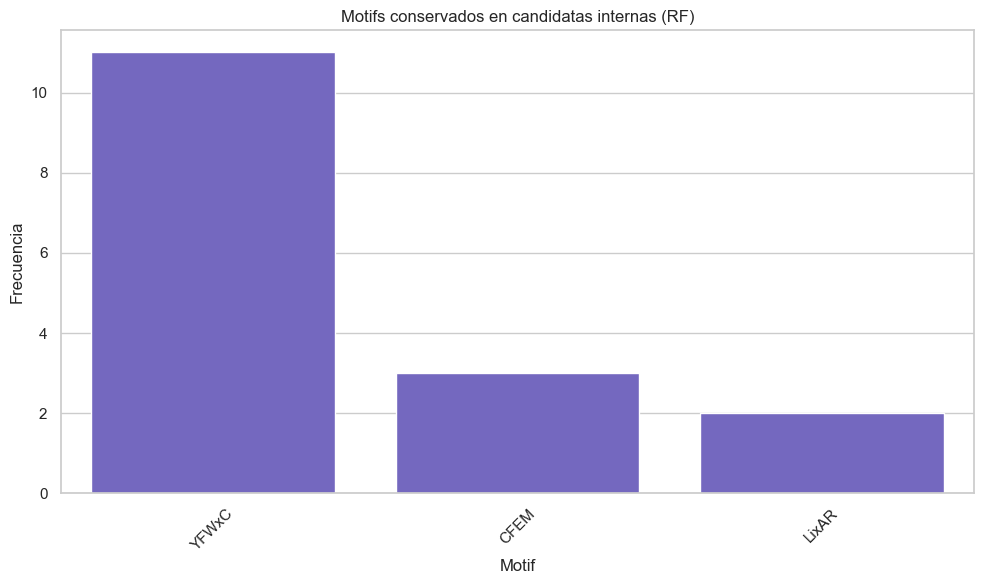

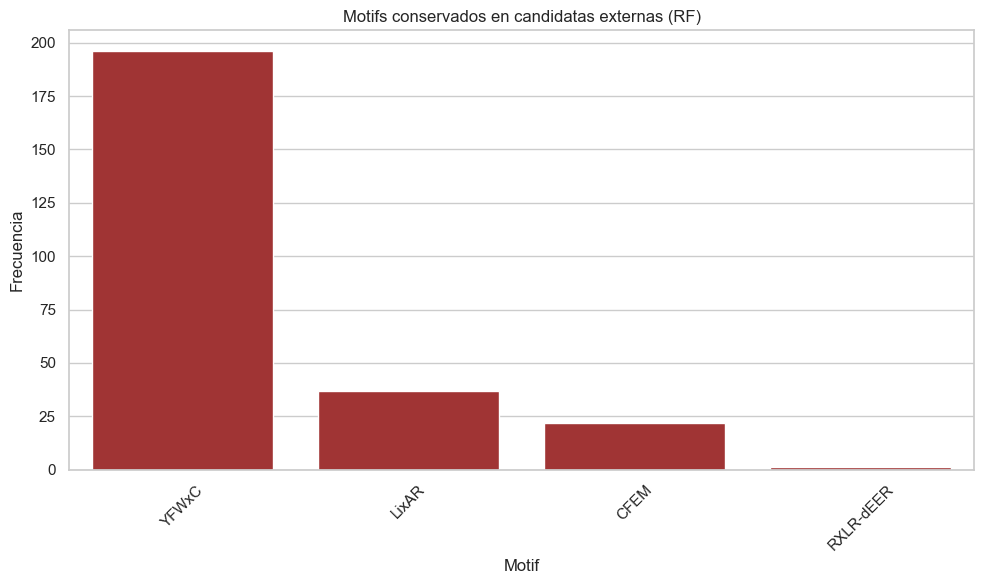

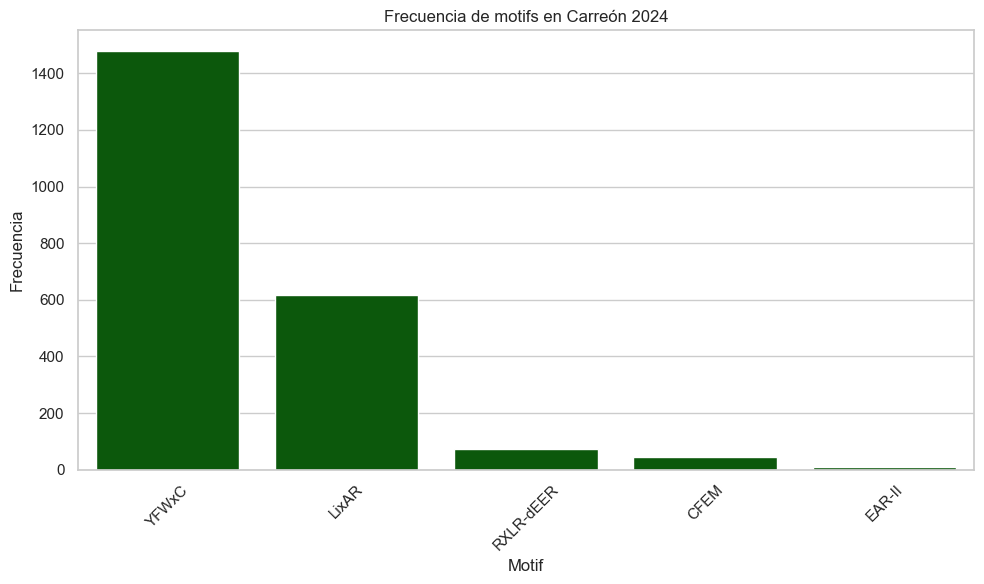

In [23]:

# =========================================================
# 15. MOTIFS EN TRAIN/TEST Y EN VALIDACIÓN EXTERNA
# =========================================================

train_df['Motifs'] = train_df['Sequence'].apply(detect_motifs)
test_df['Motifs'] = test_df['Sequence'].apply(detect_motifs)
train_df['DatasetSplit'] = 'Train'
test_df['DatasetSplit'] = 'Test'
internal_motifs_df = pd.concat([train_df[['Protein_ID', 'Label', 'DatasetSplit', 'Motifs']],
                                test_df[['Protein_ID', 'Label', 'DatasetSplit', 'Motifs']]], ignore_index=True)

internal_candidate_df = test_df.copy()
internal_candidate_df['PredictedLabel'] = results['RandomForest']['pred']
internal_candidate_df['EffectorProbability'] = results['RandomForest']['prob']
internal_candidate_df = internal_candidate_df[internal_candidate_df['PredictedLabel'] == 1].copy()

motif_internal_all = motif_frequency_table(internal_motifs_df['Motifs'], label='Count')
motif_internal_candidates = motif_frequency_table(internal_candidate_df['Motifs'], label='CandidateCount')
motif_external_all = motif_frequency_table(ext_df['Motifs'], label='ExternalCount')
motif_external_candidates = motif_frequency_table(ext_df.loc[ext_df['PredictedLabel'] == 1, 'Motifs'], label='ExternalCandidateCount')

motif_internal_all.to_csv(OUTPUT_DIR / 'motif_frequency_internal_all.csv', index=False)
motif_internal_candidates.to_csv(OUTPUT_DIR / 'motif_frequency_internal_candidates_rf.csv', index=False)
motif_external_all.to_csv(OUTPUT_DIR / 'motif_frequency_external_all.csv', index=False)
motif_external_candidates.to_csv(OUTPUT_DIR / 'motif_frequency_external_candidates_rf.csv', index=False)

print('Distribución motifs internas (todas):')
print(motif_internal_all.head(15))
print('Distribución motifs internas (candidatas RF en test):')
print(motif_internal_candidates.head(15))
print('Frecuencia motifs dataset externo completo:')
print(motif_external_all.head(15))
print('Frecuencia motifs candidatas externas RF:')
print(motif_external_candidates.head(15))

if not motif_internal_candidates.empty:
    save_barplot(motif_internal_candidates.head(15), 'Motif', 'CandidateCount',
                 'Motifs conservados en candidatas internas (RF)', 'Motif', 'Frecuencia',
                 OUTPUT_DIR / 'motifs_internal_candidates_barplot.png', color='slateblue', rotate=45)

if not motif_external_candidates.empty:
    save_barplot(motif_external_candidates.head(15), 'Motif', 'ExternalCandidateCount',
                 'Motifs conservados en candidatas externas (RF)', 'Motif', 'Frecuencia',
                 OUTPUT_DIR / 'motifs_external_candidates_barplot.png', color='firebrick', rotate=45)

if not motif_external_all.empty:
    save_barplot(motif_external_all.head(15), 'Motif', 'ExternalCount',
                 'Frecuencia de motifs en Carreón 2024', 'Motif', 'Frecuencia',
                 OUTPUT_DIR / 'motifs_external_all_barplot.png', color='darkgreen', rotate=45)


  ClassOfEffector  PredictedLabel  Count
0       canonical               0      1
1       canonical               1    279
2   non-canonical               0   2679
3   non-canonical               1     51


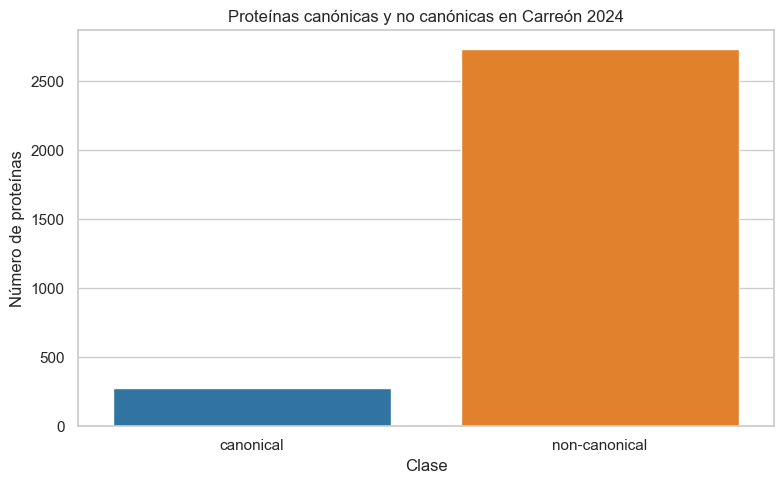

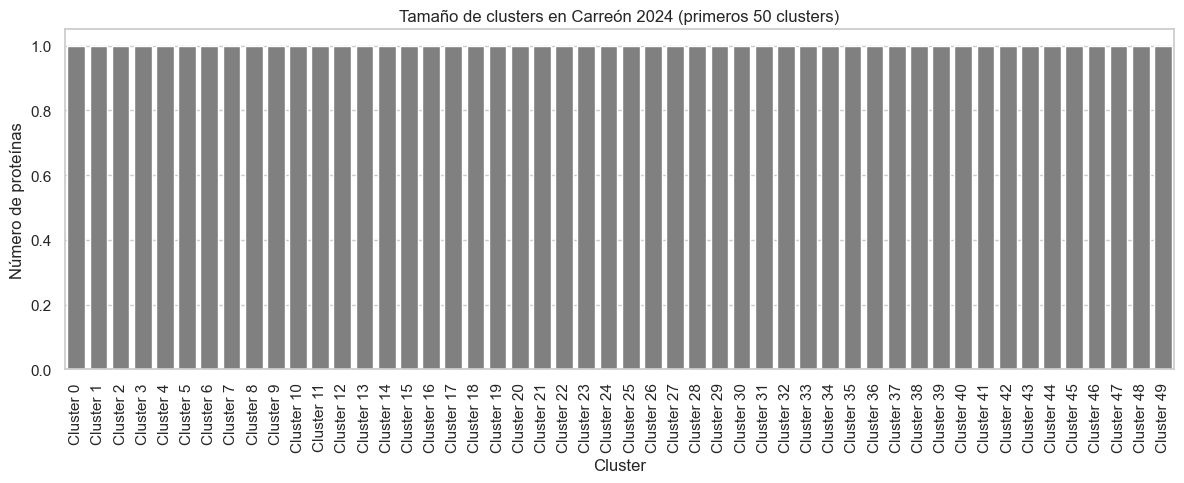

Faltan: []


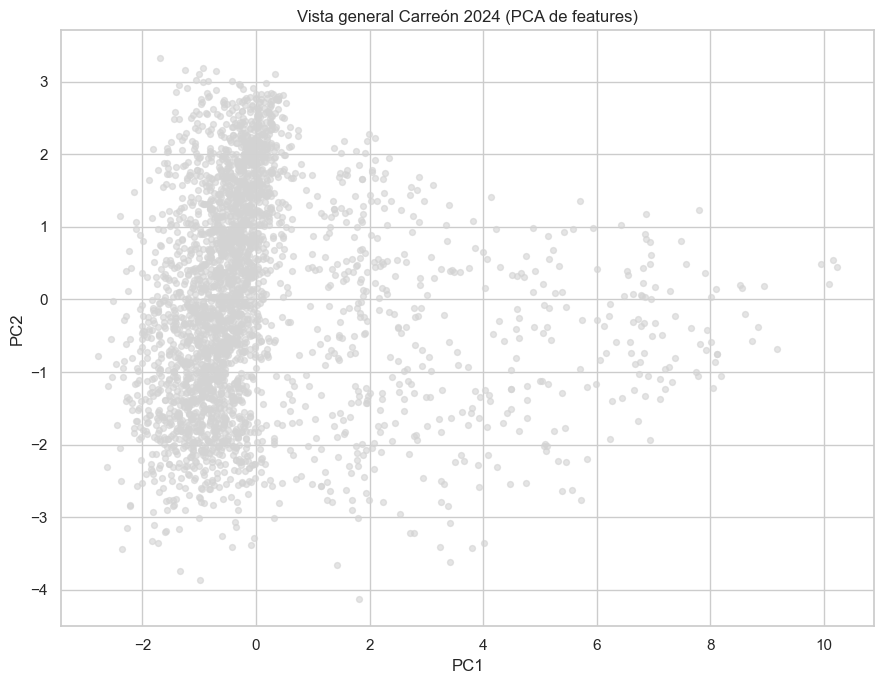

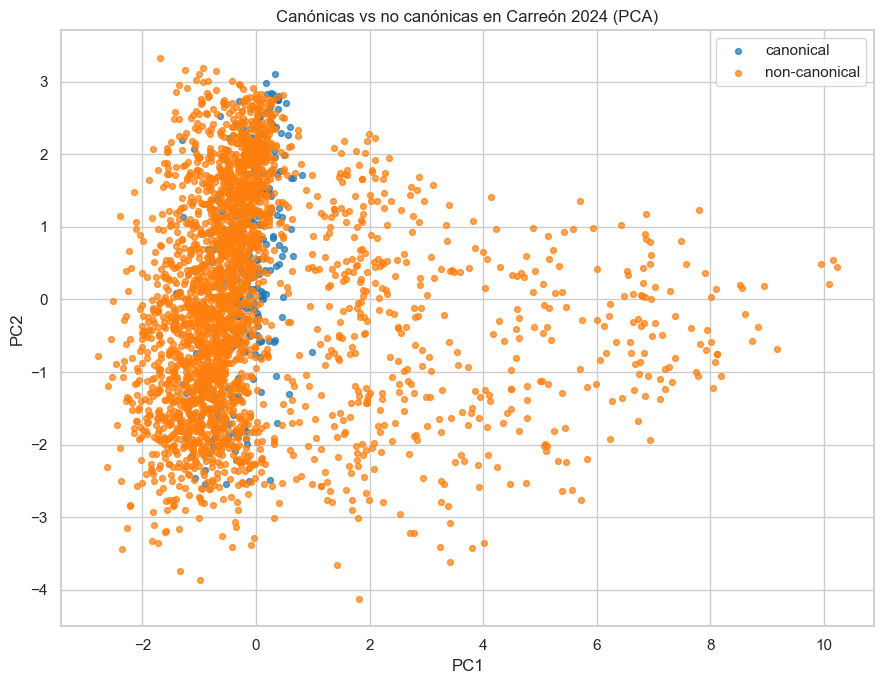

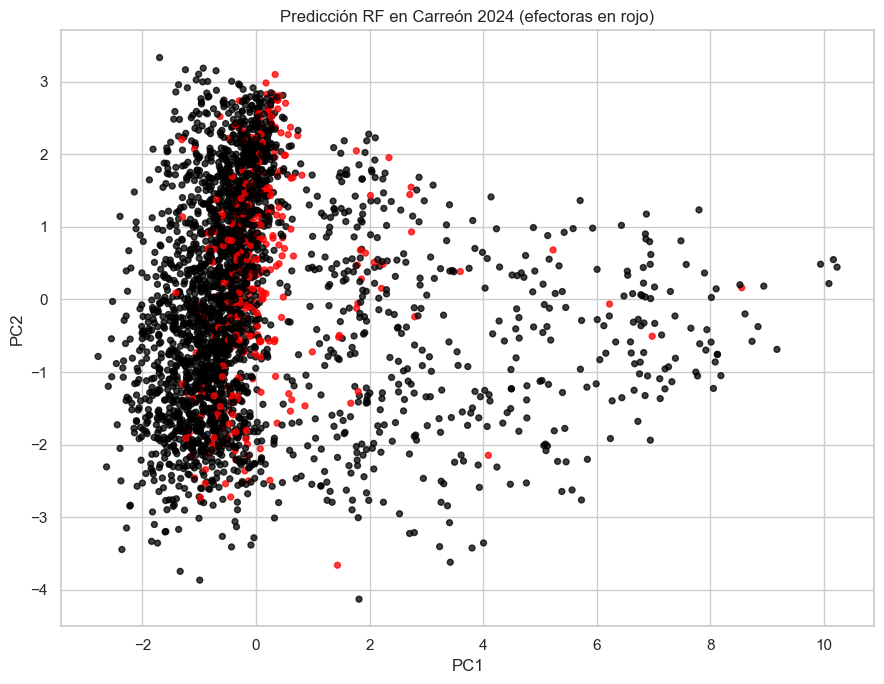

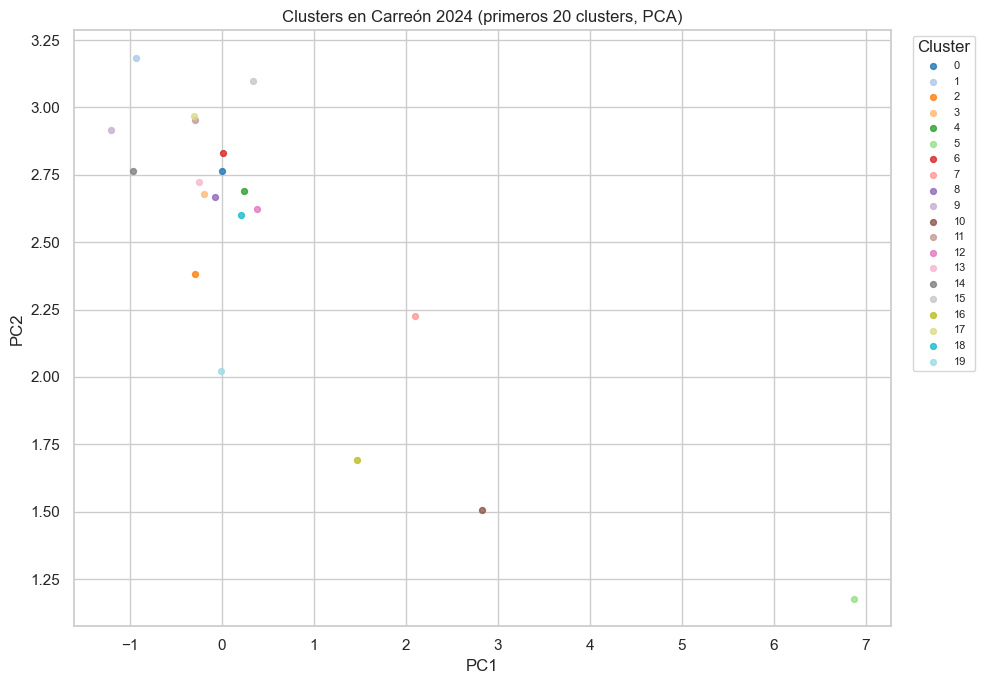

In [28]:

# =========================================================
# 16. CANÓNICAS, NO CANÓNICAS Y VISUALIZACIÓN DEL DATASET EXTERNO
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from Bio.SeqUtils.ProtParam import ProteinAnalysis

def extract_cluster_numeric(cluster_series):
    return pd.to_numeric(
        cluster_series.astype(str).str.extract(r'(\d+)')[0],
        errors='coerce'
    )

def extract_physicochem_features(seq):
    prot = ProteinAnalysis(str(seq).upper())
    aa = prot.amino_acids_percent if hasattr(prot, "amino_acids_percent") else prot.get_amino_acids_percent()
    return pd.Series({
        "CysPercent": aa.get("C", 0) * 100,
        "MolecularWeight": prot.molecular_weight(),
        "Aromaticity": prot.aromaticity(),
        "Instability": prot.instability_index(),
        "IsoelectricPoint": prot.isoelectric_point(),
        "Gravy": prot.gravy()
    })

if not all(c in ext_df.columns for c in ["CysPercent", "MolecularWeight", "Aromaticity", "Instability", "IsoelectricPoint", "Gravy"]):
    physchem_df = ext_df["Sequence"].apply(extract_physicochem_features)
    ext_df = pd.concat([ext_df.reset_index(drop=True), physchem_df.reset_index(drop=True)], axis=1)

canonical_summary = (
    ext_df.groupby(["ClassOfEffector", "PredictedLabel"])
    .size()
    .reset_index(name="Count")
)
canonical_summary.to_csv(OUTPUT_DIR / "canonical_noncanonical_summary_external.csv", index=False)
print(canonical_summary)

plt.figure(figsize=(8, 5))
plot_df = ext_df.groupby("ClassOfEffector").size().reset_index(name="Count")
sns.barplot(data=plot_df, x="ClassOfEffector", y="Count", palette=["#1f77b4", "#ff7f0e"])
plt.title("Proteínas canónicas y no canónicas en Carreón 2024")
plt.xlabel("Clase")
plt.ylabel("Número de proteínas")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "canonical_noncanonical_external_barplot.png", dpi=300, bbox_inches="tight")
plt.show()

cluster_counts = ext_df.groupby("Cluster").size().reset_index(name="ProteinsPerCluster")
cluster_counts["ClusterNumeric"] = extract_cluster_numeric(cluster_counts["Cluster"])
cluster_counts = cluster_counts.sort_values(["ClusterNumeric", "Cluster"]).reset_index(drop=True)
cluster_counts.to_csv(OUTPUT_DIR / "external_cluster_table.csv", index=False)

plt.figure(figsize=(12, 5))
cluster_plot = cluster_counts.head(50).copy()
cluster_plot["ClusterLabel"] = cluster_plot["Cluster"].astype(str)
sns.barplot(data=cluster_plot, x="ClusterLabel", y="ProteinsPerCluster", color="gray")
plt.title("Tamaño de clusters en Carreón 2024 (primeros 50 clusters)")
plt.xlabel("Cluster")
plt.ylabel("Número de proteínas")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "external_cluster_sizes_top50.png", dpi=300, bbox_inches="tight")
plt.show()

pca_features = [
    "Length", "SP_probability", "ExpAA", "PredHel", "TM_present",
    "CysPercent", "MolecularWeight", "Aromaticity",
    "Instability", "IsoelectricPoint", "Gravy"
]

missing = [c for c in pca_features if c not in ext_df.columns]
print("Faltan:", missing)

pca_source = ext_df[pca_features].copy()
pca_source = pca_source.replace([np.inf, -np.inf], np.nan).dropna()

scaler = StandardScaler()
pca_scaled = scaler.fit_transform(pca_source)

pca_model = PCA(n_components=2, random_state=42)
pca_coords = pca_model.fit_transform(pca_scaled)

pca_df = pd.DataFrame({
    "PC1": pca_coords[:, 0],
    "PC2": pca_coords[:, 1],
    "Protein_ID": ext_df.loc[pca_source.index, "Protein_ID"].astype(str).values,
    "Cluster": ext_df.loc[pca_source.index, "Cluster"].astype(str).values,
    "ClassOfEffector": ext_df.loc[pca_source.index, "ClassOfEffector"].astype(str).values,
    "PredictedLabel": ext_df.loc[pca_source.index, "PredictedLabel"].astype(int).values,
    "EffectorProbability": ext_df.loc[pca_source.index, "EffectorProbability"].astype(float).values
})
pca_df.to_csv(OUTPUT_DIR / "external_pca_coordinates.csv", index=False)

plt.figure(figsize=(9, 7))
plt.scatter(pca_df["PC1"], pca_df["PC2"], c="lightgray", s=18, alpha=0.6)
plt.title("Vista general Carreón 2024 (PCA de features)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "external_pca_all_proteins.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 7))
canon_map = {"canonical": "#1f77b4", "non-canonical": "#ff7f0e"}
for cls, color in canon_map.items():
    sub = pca_df[pca_df["ClassOfEffector"] == cls]
    if len(sub) > 0:
        plt.scatter(sub["PC1"], sub["PC2"], c=color, s=18, alpha=0.7, label=cls)
plt.title("Canónicas vs no canónicas en Carreón 2024 (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "external_pca_canonical_vs_noncanonical.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 7))
colors = np.where(pca_df["PredictedLabel"] == 1, "red", "black")
plt.scatter(pca_df["PC1"], pca_df["PC2"], c=colors, s=18, alpha=0.75)
plt.title("Predicción RF en Carreón 2024 (efectoras en rojo)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "external_pca_predicted_effectors_red_black.png", dpi=300, bbox_inches="tight")
plt.show()

sample_clusters = cluster_counts.head(20)["Cluster"].astype(str).tolist()
sample_df = pca_df[pca_df["Cluster"].isin(sample_clusters)].copy()

plt.figure(figsize=(10, 7))
palette = sns.color_palette("tab20", n_colors=max(1, len(sample_clusters)))
cluster_color_map = {cl: palette[i % len(palette)] for i, cl in enumerate(sample_clusters)}

for cl in sample_clusters:
    sub = sample_df[sample_df["Cluster"] == cl]
    if len(sub) > 0:
        plt.scatter(sub["PC1"], sub["PC2"], s=18, alpha=0.8, label=cl.replace("Cluster ", ""), color=cluster_color_map[cl])

plt.title("Clusters en Carreón 2024 (primeros 20 clusters, PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "external_pca_clusters_top20.png", dpi=300, bbox_inches="tight")
plt.show()

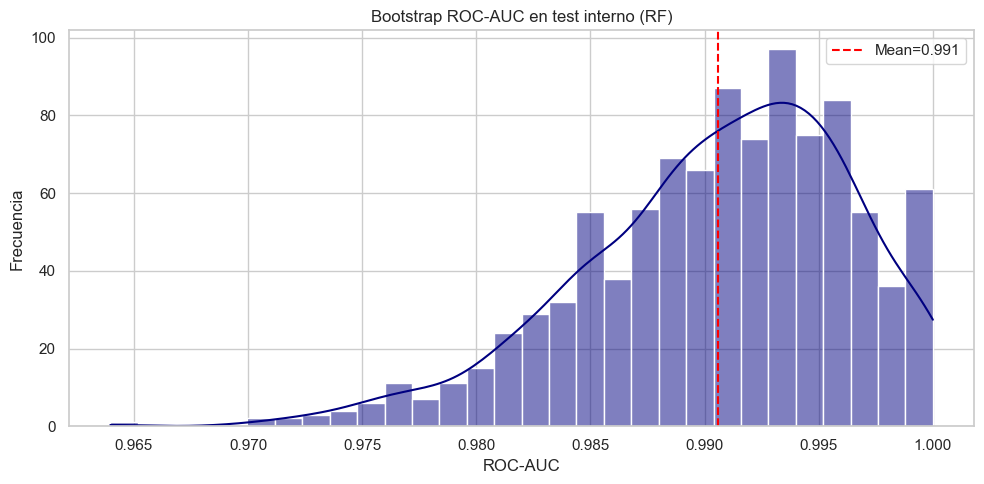

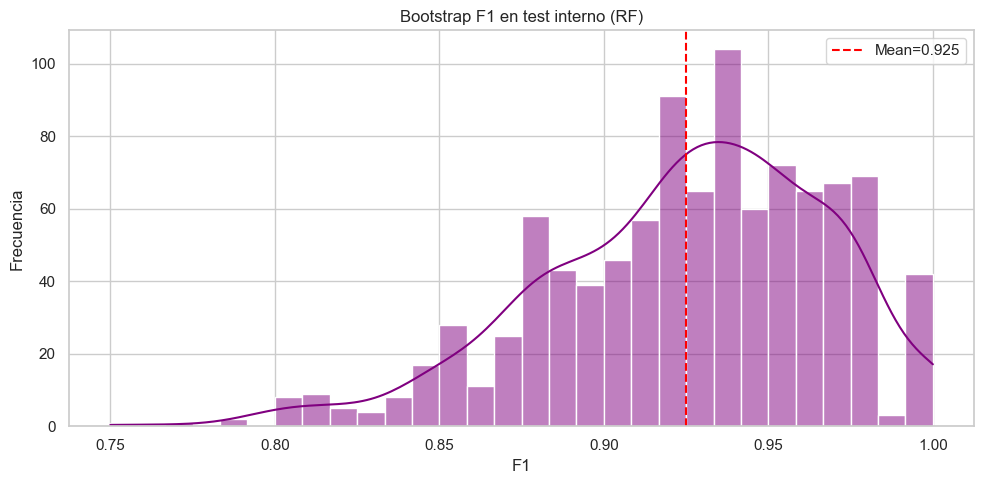

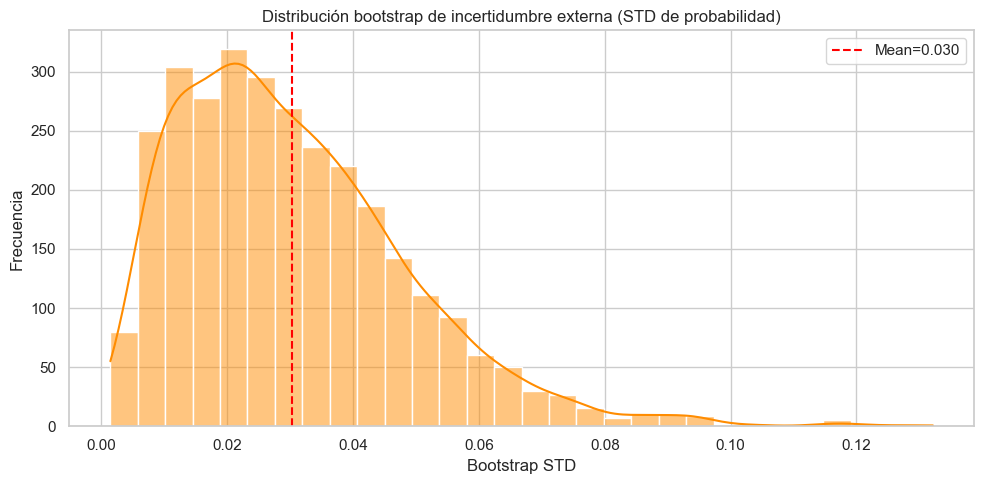

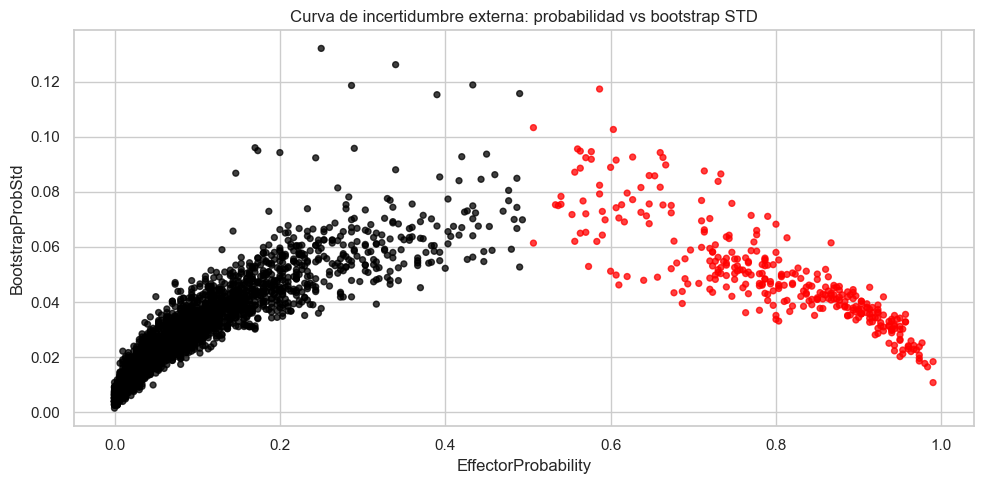

In [29]:

# =========================================================
# 17. CURVAS BOOTSTRAP: ENTRENAMIENTO Y VALIDACIÓN EXTERNA
# =========================================================

def bootstrap_metric_distribution(y_true, values, metric_fn, n_iter=1000, seed=42):
    y_true = np.asarray(y_true)
    values = np.asarray(values)
    rng = np.random.default_rng(seed)
    scores = []
    n = len(y_true)
    for _ in range(n_iter):
        idx = rng.integers(0, n, size=n)
        yt = y_true[idx]
        yp = values[idx]
        if metric_fn is roc_auc_score and len(np.unique(yt)) < 2:
            continue
        scores.append(metric_fn(yt, yp))
    return np.array(scores, dtype=float)

train_boot_auc = bootstrap_metric_distribution(y_test.values, results['RandomForest']['prob'], roc_auc_score, n_iter=1000, seed=42)
train_boot_f1 = bootstrap_metric_distribution(y_test.values, results['RandomForest']['pred'], f1_score, n_iter=1000, seed=42)

boot_training_df = pd.DataFrame({'ROC_AUC': train_boot_auc, 'F1': train_boot_f1[:len(train_boot_auc)] if len(train_boot_f1) >= len(train_boot_auc) else np.pad(train_boot_f1, (0, max(0, len(train_boot_auc)-len(train_boot_f1))), constant_values=np.nan)})
boot_training_df.to_csv(OUTPUT_DIR / 'bootstrap_training_distributions.csv', index=False)

plt.figure(figsize=(10, 5))
sns.histplot(train_boot_auc, bins=30, kde=True, color='navy')
plt.axvline(np.mean(train_boot_auc), color='red', linestyle='--', label=f"Mean={np.mean(train_boot_auc):.3f}")
plt.title('Bootstrap ROC-AUC en test interno (RF)')
plt.xlabel('ROC-AUC')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'bootstrap_training_auc_hist.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(train_boot_f1, bins=30, kde=True, color='purple')
plt.axvline(np.mean(train_boot_f1), color='red', linestyle='--', label=f"Mean={np.mean(train_boot_f1):.3f}")
plt.title('Bootstrap F1 en test interno (RF)')
plt.xlabel('F1')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'bootstrap_training_f1_hist.png', dpi=300, bbox_inches='tight')
plt.show()

external_std_values = ext_df['BootstrapProbStd'].dropna().values
external_mean_values = ext_df['BootstrapProbMean'].dropna().values
boot_external_df = ext_df[['Protein_ID', 'EffectorProbability', 'BootstrapProbMean', 'BootstrapProbStd', 'BootstrapProbCI_low', 'BootstrapProbCI_high']].copy()
boot_external_df.to_csv(OUTPUT_DIR / 'bootstrap_external_uncertainty_table.csv', index=False)

plt.figure(figsize=(10, 5))
sns.histplot(external_std_values, bins=30, kde=True, color='darkorange')
plt.axvline(np.mean(external_std_values), color='red', linestyle='--', label=f"Mean={np.mean(external_std_values):.3f}")
plt.title('Distribución bootstrap de incertidumbre externa (STD de probabilidad)')
plt.xlabel('Bootstrap STD')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'bootstrap_external_std_hist.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(ext_df['EffectorProbability'], ext_df['BootstrapProbStd'], c=np.where(ext_df['PredictedLabel'] == 1, 'red', 'black'), s=18, alpha=0.75)
plt.title('Curva de incertidumbre externa: probabilidad vs bootstrap STD')
plt.xlabel('EffectorProbability')
plt.ylabel('BootstrapProbStd')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'bootstrap_external_probability_vs_std.png', dpi=300, bbox_inches='tight')
plt.show()
